In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [3]:
def BasicSummary(df, dgts=3):
    m = df.shape[1]
    varNames = df.columns.tolist()
    varType = [''] * m
    topLevel = [''] * m
    topCount = [0] * m
    missCount = [0] * m
    levels = [0] * m

    for i in range(m):
        x = df.iloc[:, i]
        varType[i] = x.dtype.name
        xtab = pd.Series(x).value_counts(dropna=False)
        levels[i] = len(xtab)
        nums = xtab.values
        maxnum = np.max(nums)
        topCount[i] = maxnum
        maxIndex = np.argmax(nums)
        lvls = xtab.index.tolist()
        topLevel[i] = lvls[maxIndex]
        missIndex = np.where((pd.isnull(x)) | (x == '') | (x == ' '))[0]
        missCount[i] = len(missIndex)

    n = df.shape[0]
    topFrac = np.round(np.array(topCount) / n)
    missFrac = np.round(np.array(missCount) / n)

    summaryFrame = pd.DataFrame({
        'variable': varNames,
        'type': varType,
        'levels': levels,
        'topLevel': topLevel,
        'topCount': topCount,
        'topFrac': topFrac,
        'missFreq': missCount,
        'missFrac': missFrac
    })

    return summaryFrame

Import Data

In [4]:
dataTrain = pd.read_csv("./DataTrain_Preliminary.csv", sep=";", na_values=["*", 99999, "#NA"])
dataTrain.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,type_of_attack
0,0.0,tcp,private,SH,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.01,0.94,0.95,0.0,0.95,1.0,0.0,0.0,nmap
1,0.0,tcp,private,S0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,0.02,0.08,0.00,0.0,1.00,1.0,0.0,0.0,neptune
2,0.0,tcp,http,SF,285.0,3623.0,0.0,0.0,0.0,0.0,...,228.0,1.00,0.00,0.01,NaN,0.00,0.0,0.0,0.0,normal
3,0.0,tcp,http,SF,232.0,584.0,0.0,0.0,0.0,0.0,...,255.0,1.00,0.00,0.17,NaN,0.00,0.0,0.0,0.0,normal
4,1.0,tcp,smtp,SF,1080.0,327.0,0.0,0.0,0.0,0.0,...,154.0,0.58,0.02,0.00,NaN,0.00,0.0,0.0,0.0,normal


EDA

In [5]:
dataTrain.shape

(112446, 42)

In [6]:
dataTrain.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'type_of_attack'],
      dtype='object')

In [7]:
dataTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112446 entries, 0 to 112445
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     111526 non-null  float64
 1   protocol_type                111778 non-null  object 
 2   service                      111426 non-null  object 
 3   flag                         111593 non-null  object 
 4   src_bytes                    111398 non-null  float64
 5   dst_bytes                    111718 non-null  float64
 6   land                         112038 non-null  float64
 7   wrong_fragment               111923 non-null  float64
 8   urgent                       112078 non-null  float64
 9   hot                          111528 non-null  float64
 10  num_failed_logins            111862 non-null  float64
 11  logged_in                    112276 non-null  float64
 12  num_compromised              111995 non-null  float64
 13 

In [8]:
dataTrain.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,111526.000000,1.113980e+05,1.117180e+05,112038.000000,111923.000000,112078.000000,111528.000000,111862.000000,112276.000000,111995.000000,...,111586.000000,111792.000000,111542.000000,111936.000000,111948.000000,77887.000000,111855.000000,106594.000000,101019.000000,106579.000000
mean,294.632158,3.712559e+04,2.121803e+04,0.000205,0.022596,0.000071,0.139167,0.000769,0.391295,0.274084,...,183.103606,116.007845,0.517808,0.083535,0.145097,0.008037,0.287145,0.289369,0.090983,0.111138
std,2675.904146,5.167993e+06,4.269651e+06,0.014326,0.252997,0.011948,1.715395,0.037336,0.488042,24.578508,...,98.631233,110.877377,0.449297,0.189395,0.305131,0.089290,0.446210,0.453472,0.287586,0.314305
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.500000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.680000e+02,5.100000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.000000,1.000000,1.000000,0.000000,0.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,4.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
BasicSummary(dataTrain)

,variable,type,levels,topLevel,topCount,topFrac,missFreq,missFrac
0,duration,float64,2664,0.0,102916,1.0,920,0.0
1,protocol_type,object,4,tcp,90997,1.0,668,0.0
2,service,object,71,http,36013,0.0,1020,0.0
3,flag,object,12,SF,65941,1.0,853,0.0
4,src_bytes,float64,3200,0.0,44030,0.0,1048,0.0
5,dst_bytes,float64,8842,0.0,60138,1.0,728,0.0
6,land,float64,3,0.0,112015,1.0,408,0.0
7,wrong_fragment,float64,4,0.0,110958,1.0,523,0.0
8,urgent,float64,5,0.0,112073,1.0,368,0.0
9,hot,float64,26,0.0,109574,1.0,918,0.0


In [10]:
for column in dataTrain.columns:
    if column != 'type_of_attack':
        unique_values = dataTrain[column].unique()
        value_counts = dataTrain[column].value_counts()

        print(f"Variable: {column}")
        print(f"Unique Values: {len(unique_values)}")
        print("Jumlah setiap nilai:")
        print(value_counts)
        print("=" * 50)

Variable: duration
Unique Values: 2664
Jumlah setiap nilai:
duration
0.0        102916
1.0          1662
2.0           709
3.0           497
4.0           286
            ...  
2238.0          1
26110.0         1
19759.0         1
1070.0          1
6457.0          1
Name: count, Length: 2663, dtype: int64
Variable: protocol_type
Unique Values: 4
Jumlah setiap nilai:
protocol_type
tcp     90997
udp     13364
icmp     7417
Name: count, dtype: int64
Variable: service
Unique Values: 71
Jumlah setiap nilai:
service
http         36013
private      19415
domain_u      8041
smtp          6563
ftp_data      5558
             ...  
tftp_u           3
aol              2
http_8001        1
harvest          1
http_2784        1
Name: count, Length: 70, dtype: int64
Variable: flag
Unique Values: 12
Jumlah setiap nilai:
flag
SF        65941
S0        31356
REJ        9956
RSTR       2155
RSTO       1364
S1          314
SH          222
S2          115
RSTOS0       91
S3           40
OTH          39
Na

In [11]:
sorted_dataTrain = dataTrain.sort_values(by = 'type_of_attack')
sorted_dataTrain

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,type_of_attack
94309,0.0,tcp,http,RSTR,54020.0,7300.0,0.0,0.0,0.0,1.0,...,255.0,1.00,0.00,0.00,0.0,0.00,0.0,NaN,NaN,Denial of Service Attack
40638,0.0,tcp,http,SF,54540.0,8314.0,0.0,0.0,0.0,2.0,...,241.0,1.00,0.00,0.00,0.0,0.00,0.0,NaN,NaN,Denial of Service Attack
58642,0.0,udp,private,SF,28.0,0.0,0.0,3.0,0.0,0.0,...,55.0,0.22,0.01,0.22,0.0,0.00,0.0,0.0,0.0,Denial of Service Attack
18363,0.0,tcp,http,SF,54540.0,8314.0,0.0,0.0,0.0,NaN,...,153.0,1.00,0.00,0.01,0.0,0.00,0.0,NaN,NaN,Denial of Service Attack
64583,0.0,tcp,http,SF,54540.0,8314.0,0.0,0.0,0.0,2.0,...,36.0,1.00,0.00,0.03,0.0,0.03,NaN,NaN,NaN,Denial of Service Attack
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110416,0.0,icmp,ecr_i,SF,1032.0,0.0,0.0,0.0,0.0,0.0,...,18.0,0.07,0.25,0.07,0.0,0.00,0.0,0.0,0.0,smurf
56499,0.0,icmp,ecr_i,SF,1032.0,0.0,0.0,0.0,0.0,0.0,...,224.0,0.88,0.02,0.88,0.0,0.00,0.0,0.0,0.0,smurf
13601,0.0,icmp,ecr_i,SF,1032.0,NaN,0.0,0.0,0.0,0.0,...,120.0,0.47,0.02,0.47,0.0,0.00,0.0,0.0,0.0,smurf
3019,0.0,icmp,ecr_i,SF,1032.0,0.0,0.0,0.0,0.0,0.0,...,185.0,0.73,0.01,0.73,0.0,0.00,0.0,0.0,0.0,smurf


# Data Preparation

In [12]:
newTrain = dataTrain

# Change Data Type of the respetive columns
newTrain = newTrain.astype({"land": object,
                            "logged_in": object,
                            "root_shell": object,
                            "su_attempted": object,
                            "is_host_login": object,
                            "is_guest_login": object,
                            "dst_host_same_src_port_rate": float,
                            "dst_host_rerror_rate": float})

In [13]:
newTrain.describe()

,duration,src_bytes,dst_bytes,wrong_fragment,urgent,hot,num_failed_logins,num_compromised,num_root,num_file_creations,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,111526.000000,1.113980e+05,1.117180e+05,111923.000000,112078.000000,111528.000000,111862.000000,111995.000000,112212.000000,112205.000000,...,111586.000000,111792.000000,111542.000000,111936.000000,111948.000000,77887.000000,111855.000000,106594.000000,101019.000000,106579.000000
mean,294.632158,3.712559e+04,2.121803e+04,0.022596,0.000071,0.139167,0.000769,0.274084,0.296127,0.012103,...,183.103606,116.007845,0.517808,0.083535,0.145097,0.008037,0.287145,0.289369,0.090983,0.111138
std,2675.904146,5.167993e+06,4.269651e+06,0.252997,0.011948,1.715395,0.037336,24.578508,24.985934,0.478063,...,98.631233,110.877377,0.449297,0.189395,0.305131,0.089290,0.446210,0.453472,0.287586,0.314305
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.500000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.680000e+02,5.100000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.000000,1.000000,1.000000,0.000000,0.000000
max,42908.000000,1.379964e+09,1.309937e+09,3.000000,3.000000,77.000000,4.000000,7479.000000,7468.000000,43.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Fill Missing value with mode for categorical and median for numerical

In [14]:
for col in newTrain.columns:
    if newTrain[col].dtype == 'object': # categorical column
        newTrain[col] = newTrain[col].fillna(newTrain[col].mode()[0])
    else: # numerical column
        newTrain[col] = newTrain[col].fillna(newTrain[col].median())


In [15]:
BasicSummary(newTrain)

,variable,type,levels,topLevel,topCount,topFrac,missFreq,missFrac
0,duration,float64,2663,0.0,103836,1.0,0,0.0
1,protocol_type,object,3,tcp,91665,1.0,0,0.0
2,service,object,70,http,37033,0.0,0,0.0
3,flag,object,11,SF,66794,1.0,0,0.0
4,src_bytes,float64,3199,0.0,44030,0.0,0,0.0
5,dst_bytes,float64,8841,0.0,60866,1.0,0,0.0
6,land,float64,2,0.0,112423,1.0,0,0.0
7,wrong_fragment,float64,3,0.0,111481,1.0,0,0.0
8,urgent,float64,4,0.0,112441,1.0,0,0.0
9,hot,float64,25,0.0,110492,1.0,0,0.0


# Visualization & Correlation Check

In [16]:
correlation_matrix = newTrain.corr()
correlation_matrix

ValueError: could not convert string to float: 'tcp'

In [ ]:
def distinguish_variable_types(dataframe):
    numerik = []  # Ini akan berisi nama kolom variabel numerik
    kategorikal = []  # Ini akan berisi nama kolom variabel kategorikal

    for column in dataframe.columns:
        if pd.api.types.is_numeric_dtype(dataframe[column]):
            numerik.append(column)
        elif pd.api.types.is_categorical_dtype(dataframe[column]) or pd.api.types.is_string_dtype(dataframe[column]):
            kategorikal.append(column)

    return numerik, kategorikal

# Panggil fungsi distinguish_variable_types
numerik, kategorikal = distinguish_variable_types(newTrain)
print("Variabel Numerik:", numerik)
print("Variabel Kategorikal:", kategorikal)


Variabel Numerik: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
Variabel Kategorikal: ['protocol_type', 'service', 'flag', 'type_of_attack']


In [ ]:
target_variable = 'type_of_attack'

# Pisahkan variabel numerik dan kategorikal
numerik, kategorikal = distinguish_variable_types(newTrain)

# Hitung korelasi antara variabel kategorikal dengan variabel kategorikal (gunakan uji chi-square)
for cat_var in kategorikal:
    if cat_var != target_variable:
        contingency_table = pd.crosstab(newTrain[target_variable], newTrain[cat_var])
        chi2, p, _, _ = stats.chi2_contingency(contingency_table)
        print(f"Korelasi antara {target_variable} dan {cat_var}: p-value = {p}")

# Hitung korelasi antara variabel kategorikal dengan variabel numerik (gunakan uji ANOVA)
for num_var in numerik:
    f_statistic, p_value = stats.f_oneway(newTrain[newTrain[target_variable] == 'normal'][num_var], newTrain[newTrain[target_variable] != 'normal'][num_var])
    print(f"Korelasi antara {target_variable} dan {num_var}: p-value = {p_value}")


Korelasi antara type_of_attack dan protocol_type: p-value = 0.0
Korelasi antara type_of_attack dan service: p-value = 0.0
Korelasi antara type_of_attack dan flag: p-value = 0.0
Korelasi antara type_of_attack dan duration: p-value = 1.9132190605207812e-20
Korelasi antara type_of_attack dan src_bytes: p-value = 1.5816629740780657e-14
Korelasi antara type_of_attack dan dst_bytes: p-value = 0.3813024421337414
Korelasi antara type_of_attack dan land: p-value = 0.8706279789954647
Korelasi antara type_of_attack dan wrong_fragment: p-value = 2.742630751111383e-88
Korelasi antara type_of_attack dan urgent: p-value = 0.24357633245082655
Korelasi antara type_of_attack dan hot: p-value = 1.2595296640910439e-33
Korelasi antara type_of_attack dan num_failed_logins: p-value = 6.695014633525374e-05
Korelasi antara type_of_attack dan logged_in: p-value = 0.0
Korelasi antara type_of_attack dan num_compromised: p-value = 0.04477036379387678
Korelasi antara type_of_attack dan root_shell: p-value = 1.29755

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:4167: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))


Korelasi antara type_of_attack dan is_guest_login: p-value = 6.905263896973064e-56
Korelasi antara type_of_attack dan count: p-value = 0.0
Korelasi antara type_of_attack dan srv_count: p-value = 0.7362030779893014
Korelasi antara type_of_attack dan serror_rate: p-value = 0.0
Korelasi antara type_of_attack dan srv_serror_rate: p-value = 0.0
Korelasi antara type_of_attack dan rerror_rate: p-value = 0.0
Korelasi antara type_of_attack dan srv_rerror_rate: p-value = 0.0
Korelasi antara type_of_attack dan same_srv_rate: p-value = 2.110386357000125e-244
Korelasi antara type_of_attack dan diff_srv_rate: p-value = 3.9952170746227205e-68
Korelasi antara type_of_attack dan srv_diff_host_rate: p-value = 0.07367789454526372
Korelasi antara type_of_attack dan dst_host_count: p-value = 0.0
Korelasi antara type_of_attack dan dst_host_srv_count: p-value = 0.0
Korelasi antara type_of_attack dan dst_host_same_srv_rate: p-value = 0.0
Korelasi antara type_of_attack dan dst_host_diff_srv_rate: p-value = 0.0

In [ ]:
# Periksa missing values dalam DataFrame
missing_values = newTrain[numerik].isnull().sum()
print(missing_values)


duration                       0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_host_rate             0
dst_host_count                 0
dst_host_srv_count             0
dst_host_s

In [ ]:
for num_var in numerik:
    f_statistic, p_value = stats.f_oneway(newTrain[newTrain[target_variable] == 'normal'][num_var], newTrain[newTrain[target_variable] != 'normal'][num_var])
    print(f"Korelasi antara {target_variable} dan {num_var}: p-value = {p_value}")


Korelasi antara type_of_attack dan duration: p-value = 1.9132190605207812e-20
Korelasi antara type_of_attack dan src_bytes: p-value = 1.5816629740780657e-14
Korelasi antara type_of_attack dan dst_bytes: p-value = 0.3813024421337414
Korelasi antara type_of_attack dan land: p-value = 0.8706279789954647
Korelasi antara type_of_attack dan wrong_fragment: p-value = 2.742630751111383e-88
Korelasi antara type_of_attack dan urgent: p-value = 0.24357633245082655
Korelasi antara type_of_attack dan hot: p-value = 1.2595296640910439e-33
Korelasi antara type_of_attack dan num_failed_logins: p-value = 6.695014633525374e-05
Korelasi antara type_of_attack dan logged_in: p-value = 0.0
Korelasi antara type_of_attack dan num_compromised: p-value = 0.04477036379387678
Korelasi antara type_of_attack dan root_shell: p-value = 1.297558254755393e-08
Korelasi antara type_of_attack dan su_attempted: p-value = 1.1684993660906515e-06
Korelasi antara type_of_attack dan num_root: p-value = 0.027403484760894315
Kore

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:4167: ConstantInputWarning: Each of the input arrays is constant;the F statistic is not defined or infinite
  warnings.warn(stats.ConstantInputWarning(msg))



Korelasi antara type_of_attack dan srv_rerror_rate: p-value = 0.0
Korelasi antara type_of_attack dan same_srv_rate: p-value = 2.110386357000125e-244
Korelasi antara type_of_attack dan diff_srv_rate: p-value = 3.9952170746227205e-68
Korelasi antara type_of_attack dan srv_diff_host_rate: p-value = 0.07367789454526372
Korelasi antara type_of_attack dan dst_host_count: p-value = 0.0
Korelasi antara type_of_attack dan dst_host_srv_count: p-value = 0.0
Korelasi antara type_of_attack dan dst_host_same_srv_rate: p-value = 0.0
Korelasi antara type_of_attack dan dst_host_diff_srv_rate: p-value = 0.0
Korelasi antara type_of_attack dan dst_host_same_src_port_rate: p-value = 2.246959408016686e-57
Korelasi antara type_of_attack dan dst_host_srv_diff_host_rate: p-value = 1.0460709830651582e-27
Korelasi antara type_of_attack dan dst_host_serror_rate: p-value = 0.0
Korelasi antara type_of_attack dan dst_host_srv_serror_rate: p-value = 0.0
Korelasi antara type_of_attack dan dst_host_rerror_rate: p-valu

In [ ]:
target_variable = 'type_of_attack'

# Pisahkan variabel numerik dan kategorikal
numerik, kategorikal = distinguish_variable_types(newTrain)

# Buat dictionary untuk menyimpan hasil uji p-value
p_values = {}

# Hitung p-value untuk setiap variabel numerik
for num_var in numerik:
    f_statistic, p_value = stats.f_oneway(newTrain[newTrain[target_variable] == 'normal'][num_var], newTrain[newTrain[target_variable] != 'normal'][num_var])
    p_values[num_var] = p_value

# Hitung p-value untuk setiap variabel kategorikal
for cat_var in kategorikal:
    if cat_var != target_variable:
        contingency_table = pd.crosstab(newTrain[target_variable], newTrain[cat_var])
        chi2, p_value, _, _ = stats.chi2_contingency(contingency_table)
        p_values[cat_var] = p_value

# Menyaring variabel dengan p-value < 0.05
significant_variables = {var: p for var, p in p_values.items() if p < 0.5}


# Menampilkan variabel-variabel yang signifikan beserta nilai p-value
for var, p_value in significant_variables.items():
    print(f"{var}: p-value = {p_value}")

duration: p-value = 1.9132190605207812e-20
src_bytes: p-value = 1.5816629740780657e-14
dst_bytes: p-value = 0.3813024421337414
wrong_fragment: p-value = 2.742630751111383e-88
urgent: p-value = 0.24357633245082655
hot: p-value = 1.2595296640910439e-33
num_failed_logins: p-value = 6.695014633525374e-05
logged_in: p-value = 0.0
num_compromised: p-value = 0.04477036379387678
root_shell: p-value = 1.297558254755393e-08
su_attempted: p-value = 1.1684993660906515e-06
num_root: p-value = 0.027403484760894315
num_file_creations: p-value = 3.331005952834593e-05
num_shells: p-value = 0.0003552958035194883
num_access_files: p-value = 4.083103670627387e-15
is_host_login: p-value = 0.3565969136063063
is_guest_login: p-value = 6.905263896973064e-56
count: p-value = 0.0
serror_rate: p-value = 0.0
srv_serror_rate: p-value = 0.0
rerror_rate: p-value = 0.0
srv_rerror_rate: p-value = 0.0
same_srv_rate: p-value = 2.110386357000125e-244
diff_srv_rate: p-value = 3.9952170746227205e-68
srv_diff_host_rate: p-v

In [ ]:
significant_variables = {var: p for var, p in p_values.items() if p == 0}

for var, p_value in significant_variables.items():
    print(f"{var}")

logged_in
count
serror_rate
srv_serror_rate
rerror_rate
srv_rerror_rate
dst_host_count
dst_host_srv_count
dst_host_same_srv_rate
dst_host_diff_srv_rate
dst_host_serror_rate
dst_host_srv_serror_rate
dst_host_rerror_rate
dst_host_srv_rerror_rate
protocol_type
service
flag


In [ ]:
significant_variables = {var: p for var, p in p_values.items() if p > 0.5}

for var, p_value in significant_variables.items():
    print(f"{var}")

land
srv_count


In [ ]:
significant_variables = {var: p for var, p in p_values.items() if 0 < p < 0.5}

for var, p_value in significant_variables.items():
    print(f"{var}")

duration
src_bytes
dst_bytes
wrong_fragment
urgent
hot
num_failed_logins
num_compromised
root_shell
su_attempted
num_root
num_file_creations
num_shells
num_access_files
is_host_login
is_guest_login
same_srv_rate
diff_srv_rate
srv_diff_host_rate
dst_host_same_src_port_rate
dst_host_srv_diff_host_rate


In [ ]:
newTrain['type_of_attack'].unique()

array(['nmap', 'neptune', 'normal', 'Denial of Service Attack',
       'portsweep', 'satan', 'ipsweep', 'smurf'], dtype=object)

In [ ]:
frequency_table = dataTrain['type_of_attack'].value_counts()
print(frequency_table)

normal                      22492
neptune                     13650
satan                        1206
ipsweep                      1206
portsweep                     970
smurf                         888
Denial of Service Attack      691
nmap                          505
Name: type_of_attack, dtype: int64


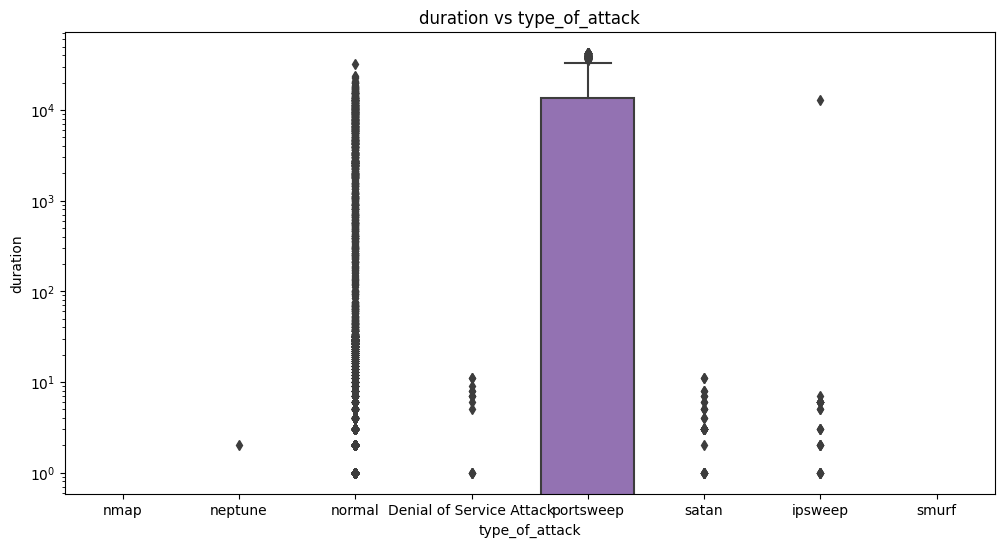

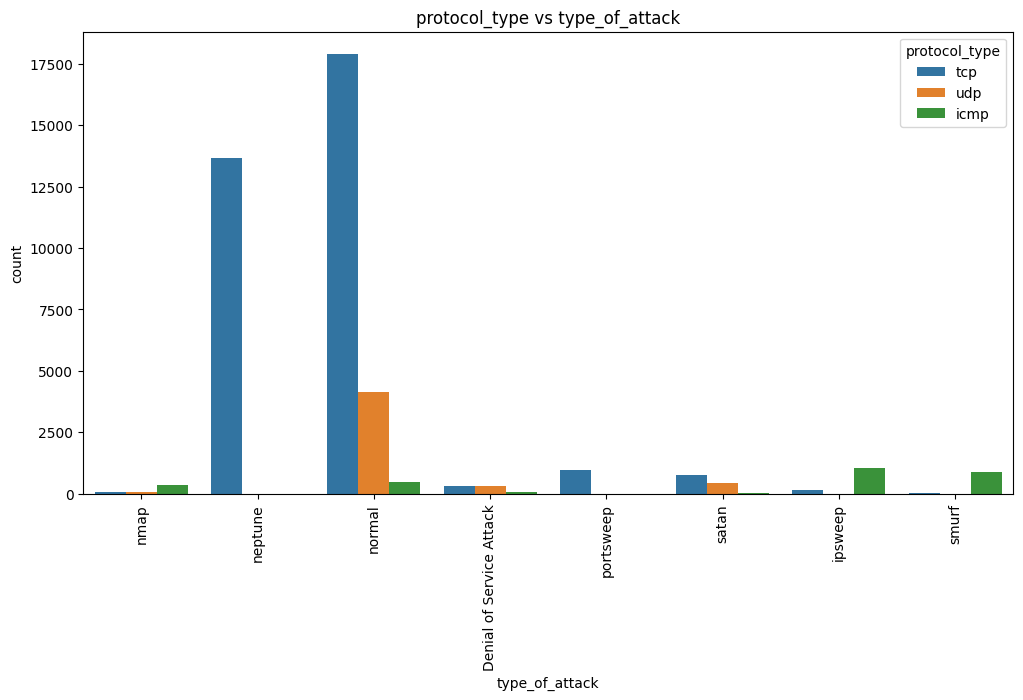

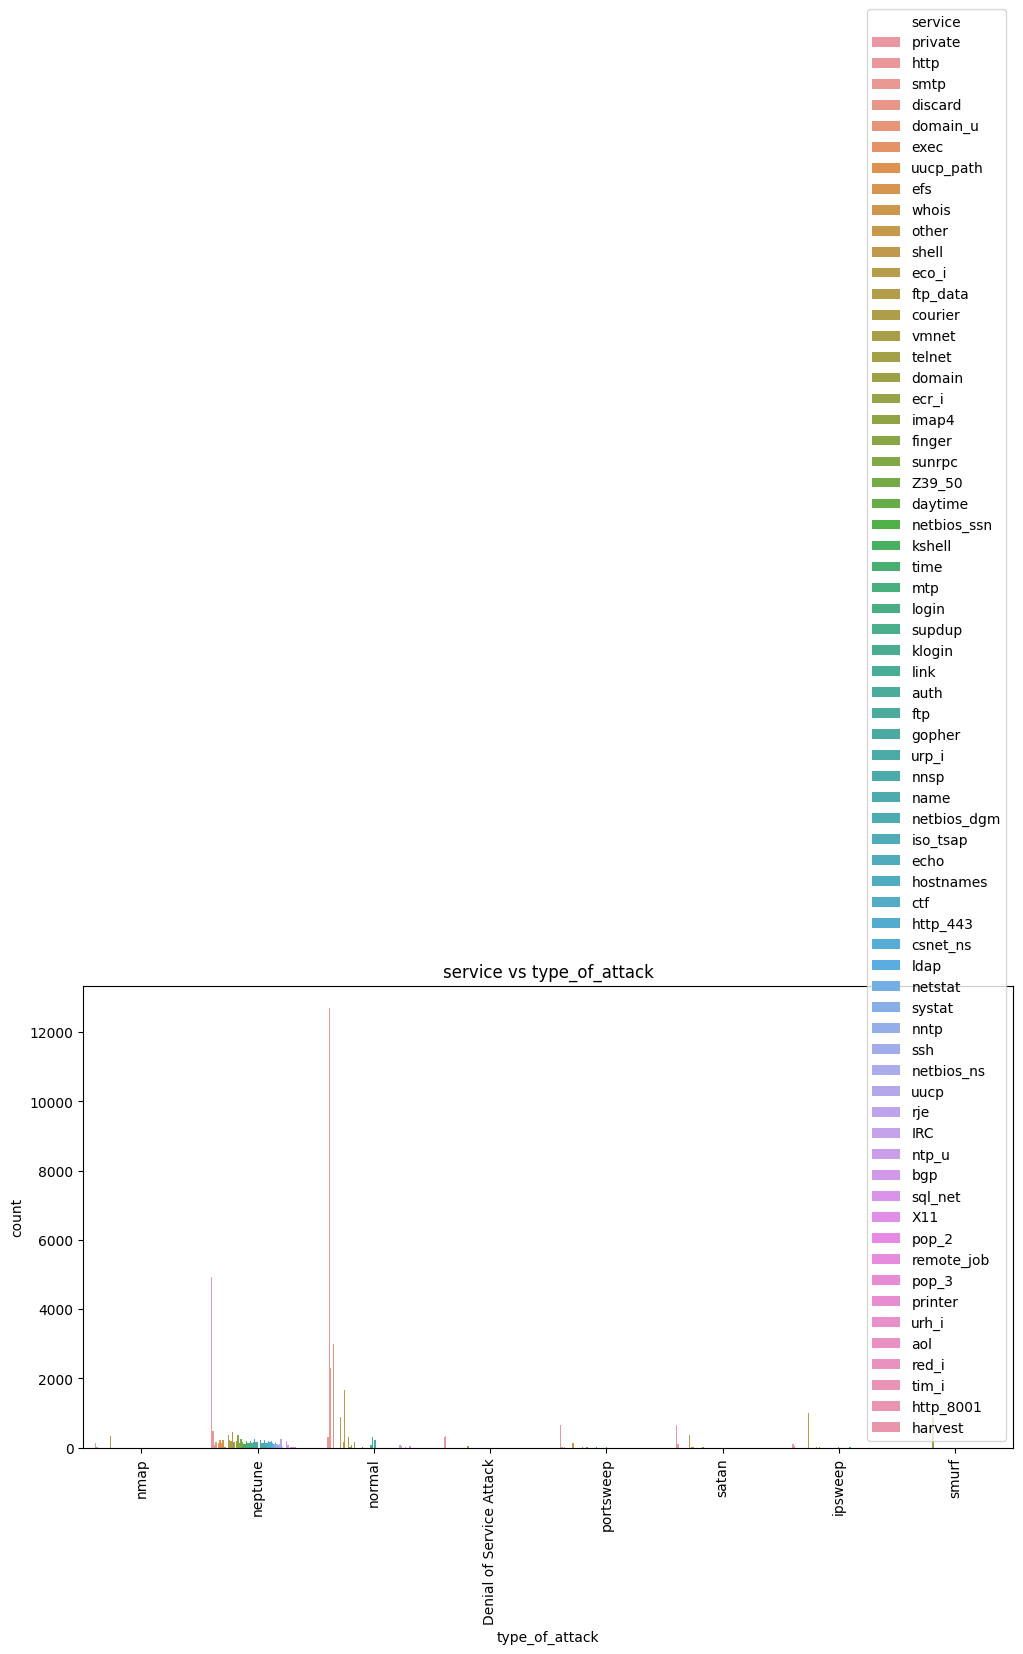

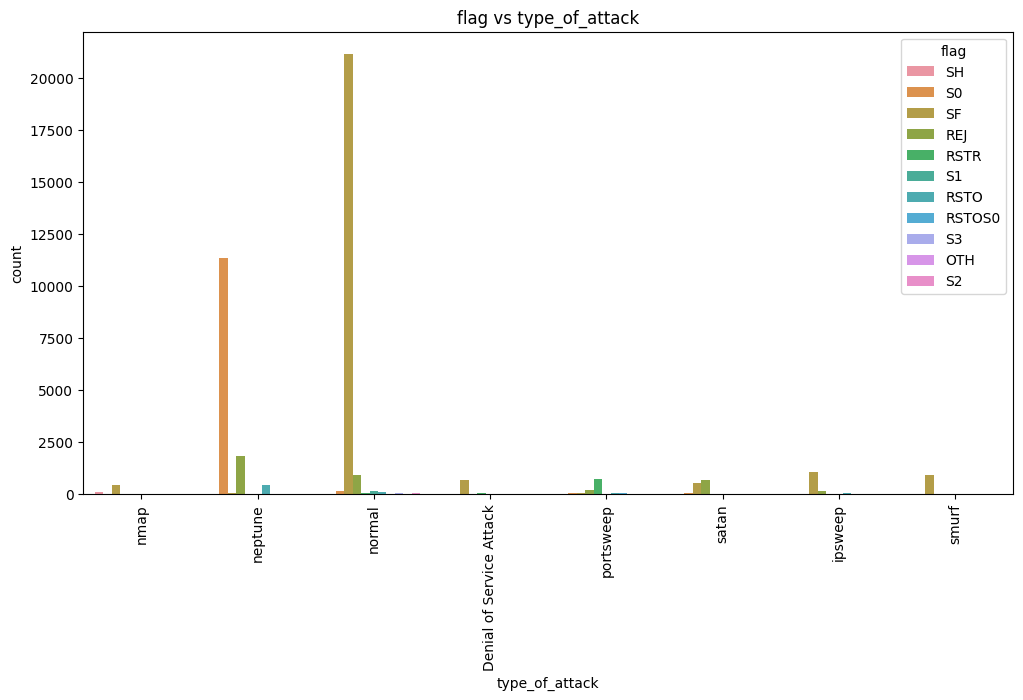

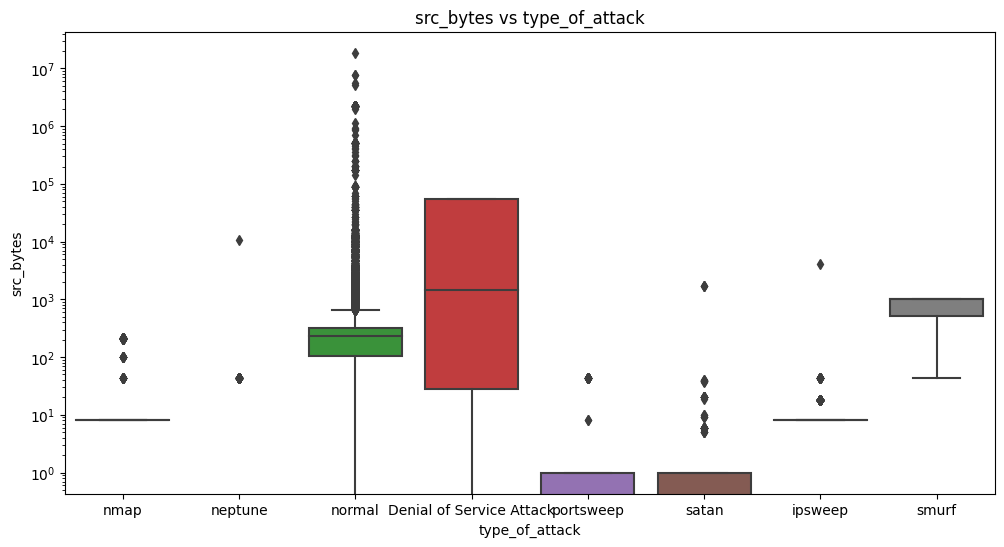

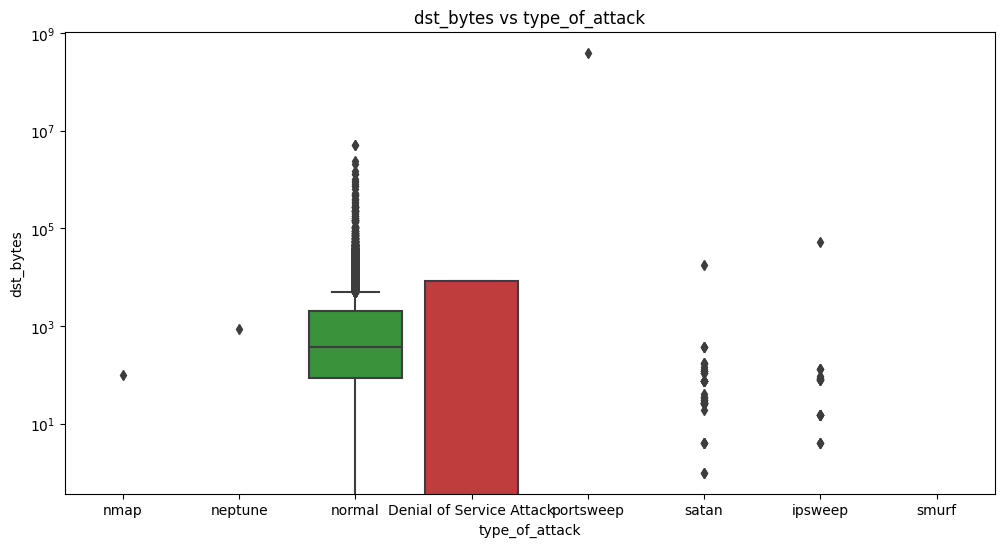

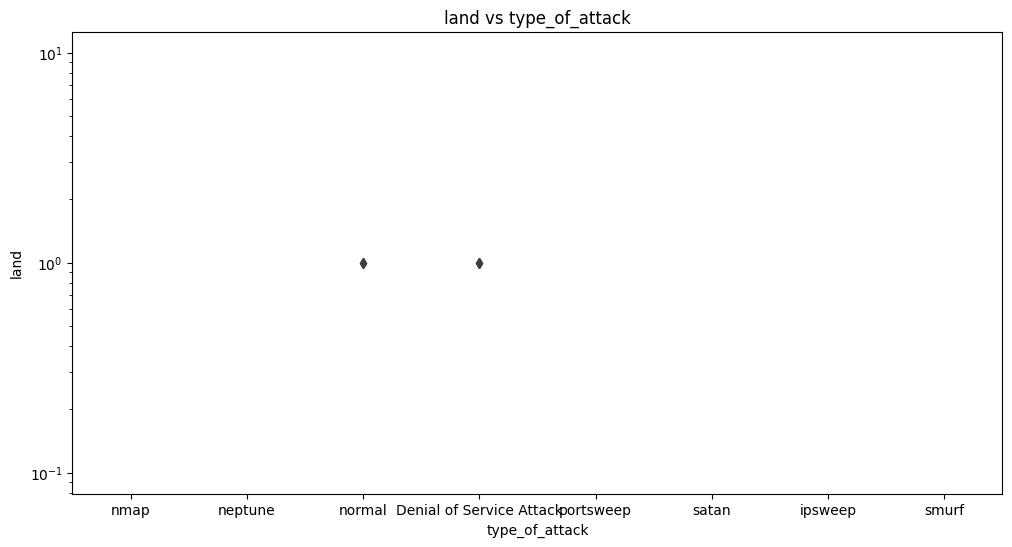

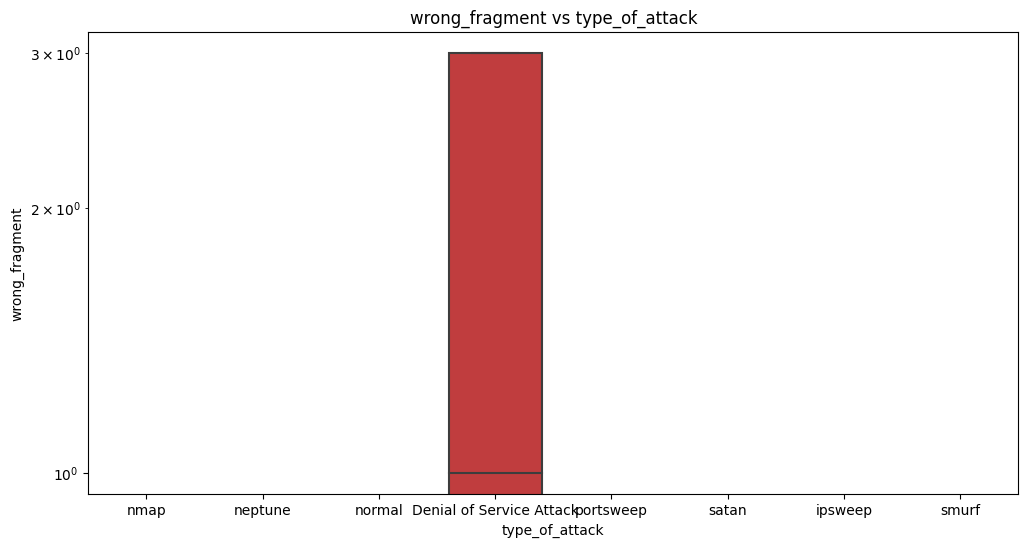

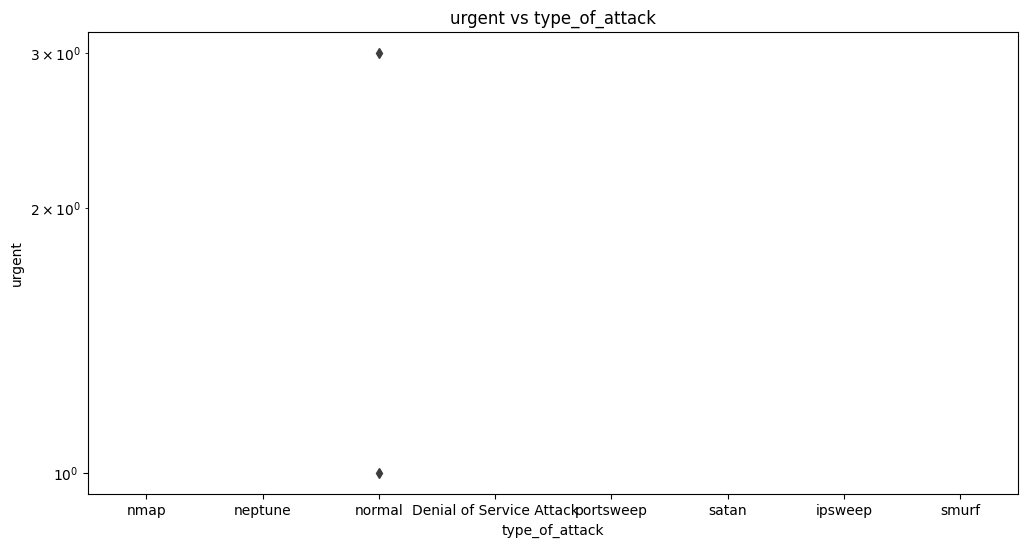

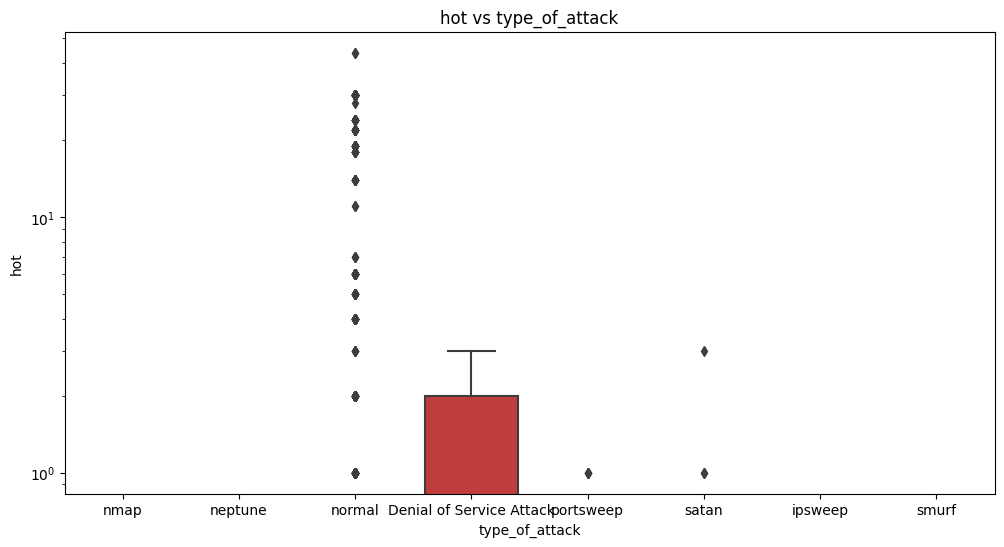

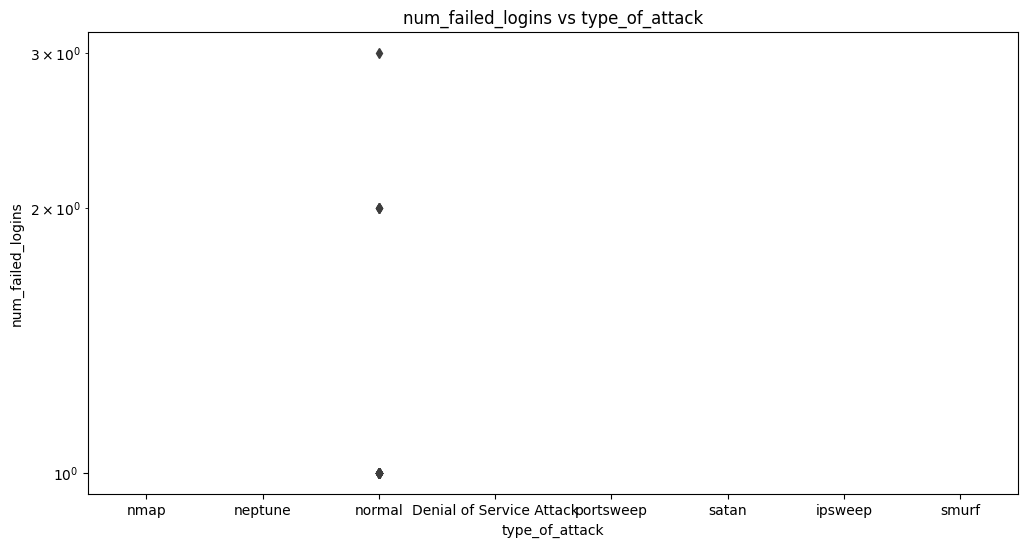

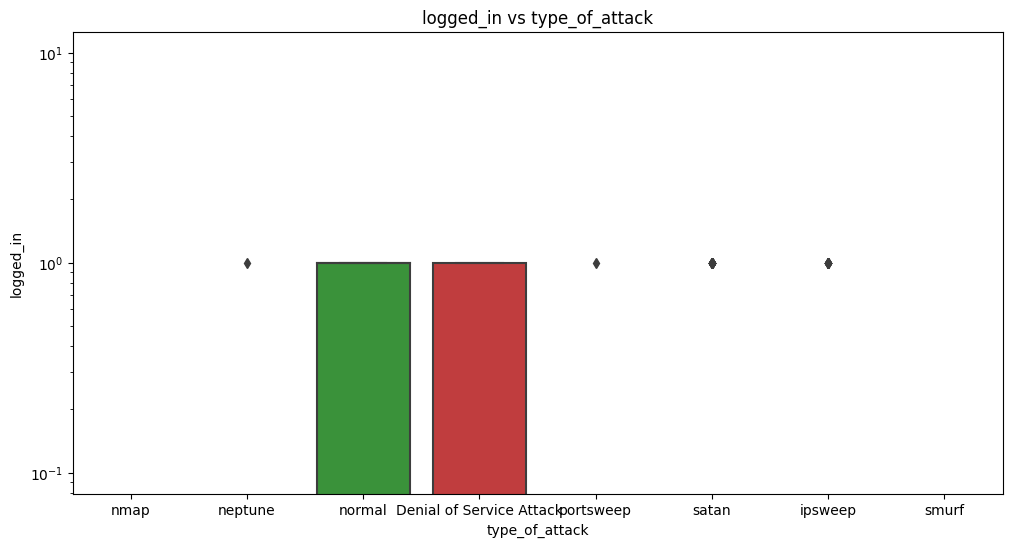

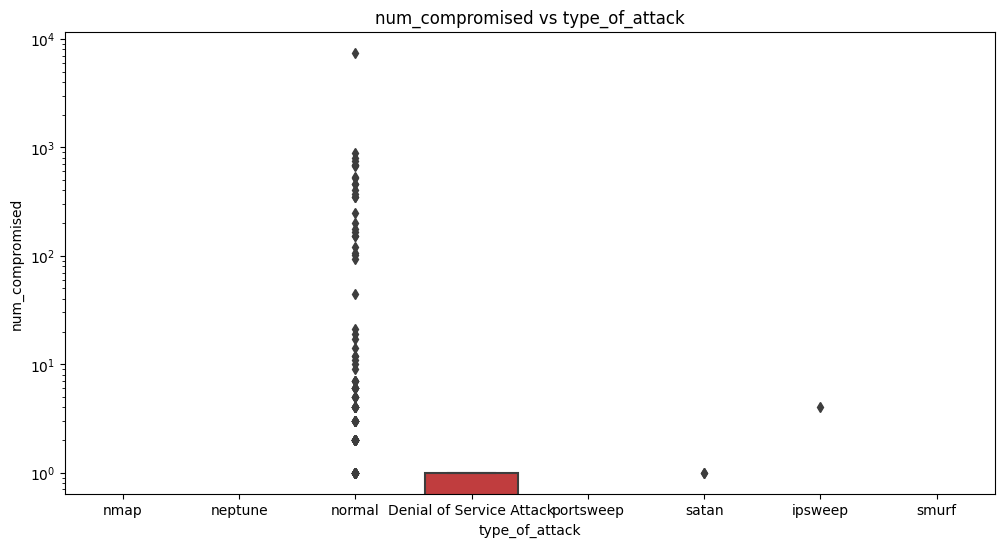

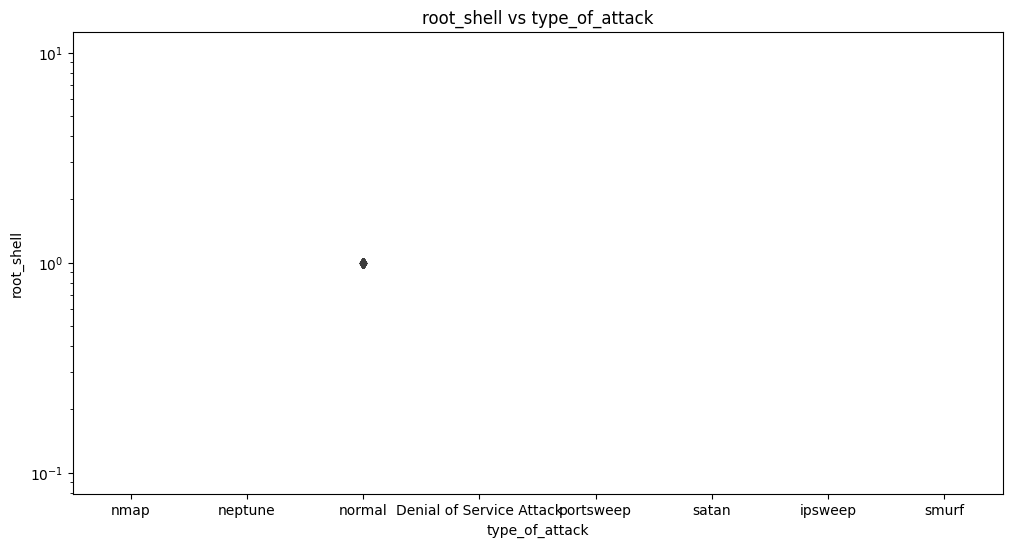

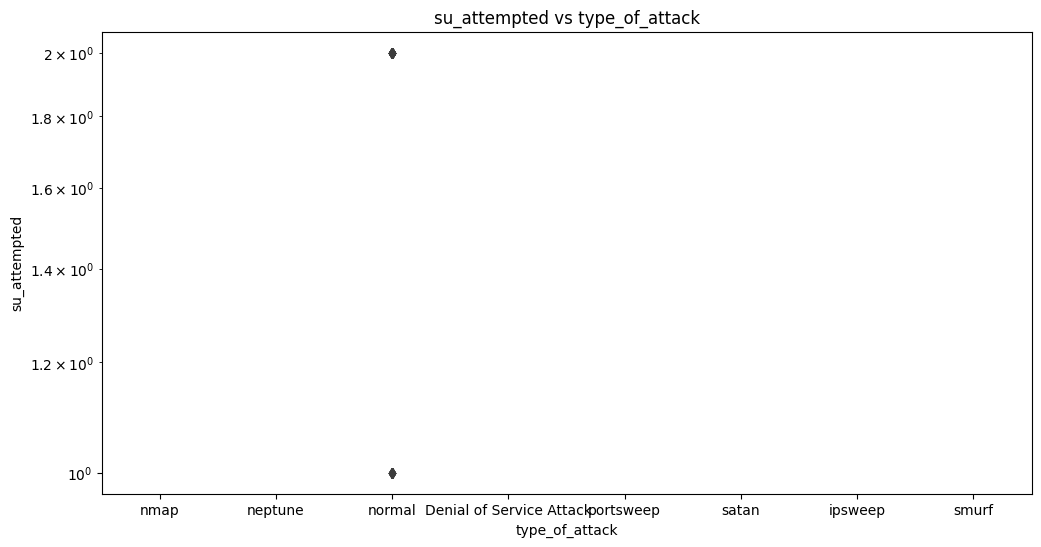

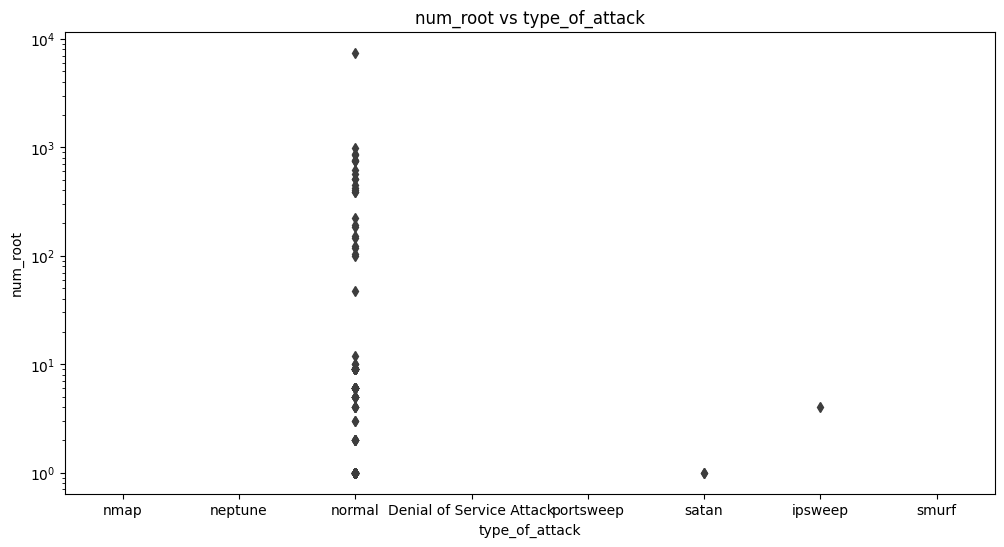

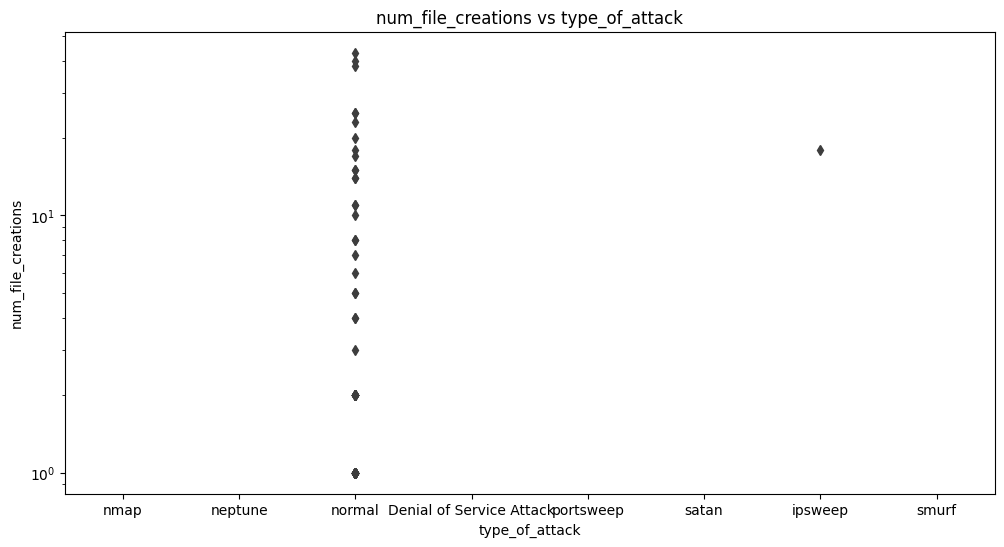

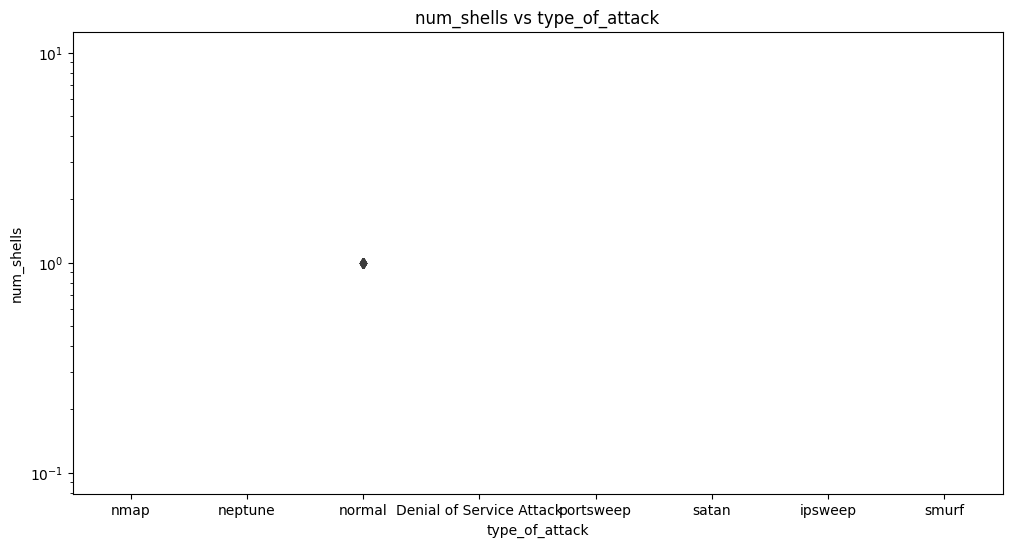

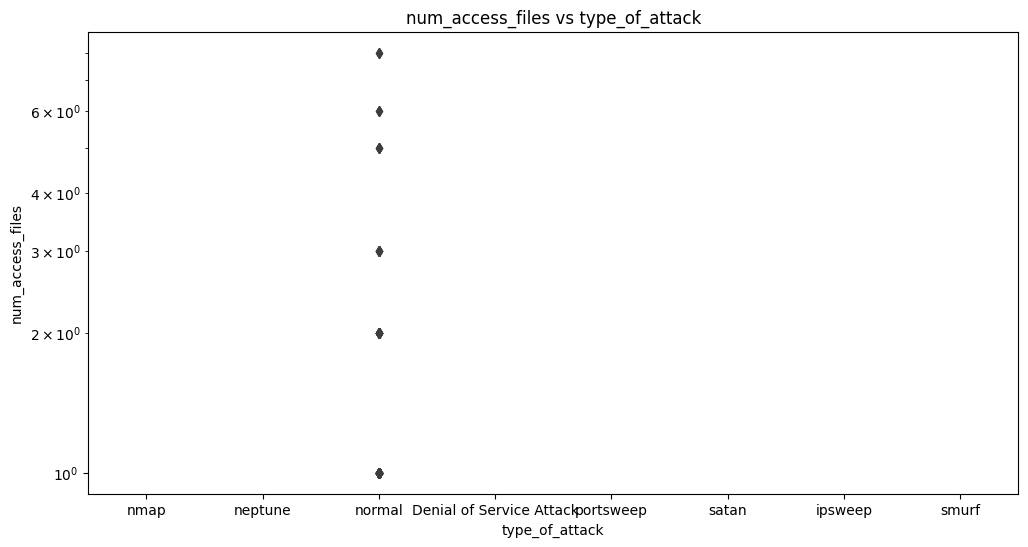

<ipython-input-26-ad2f337a2176>:14: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale('log')  # Jika skala logaritmik diperlukan


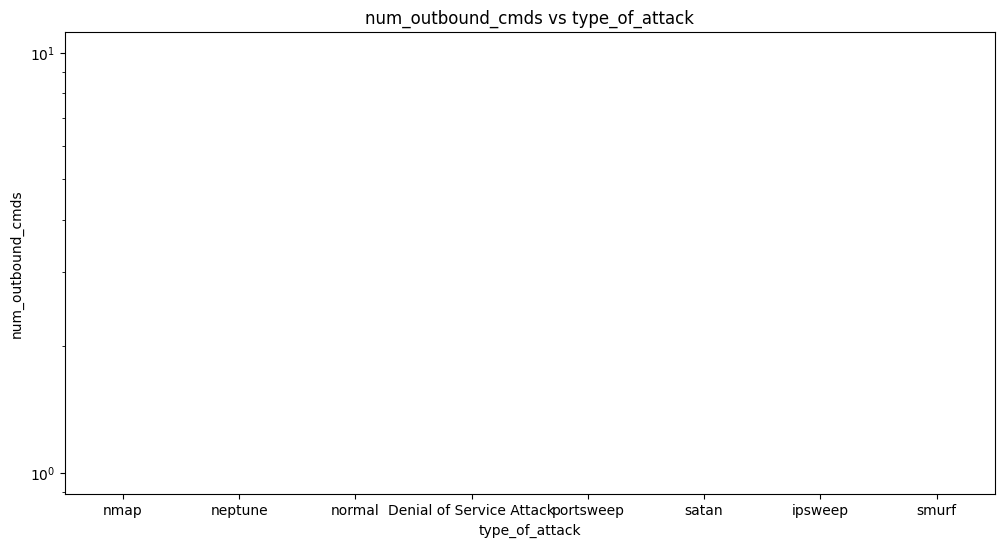

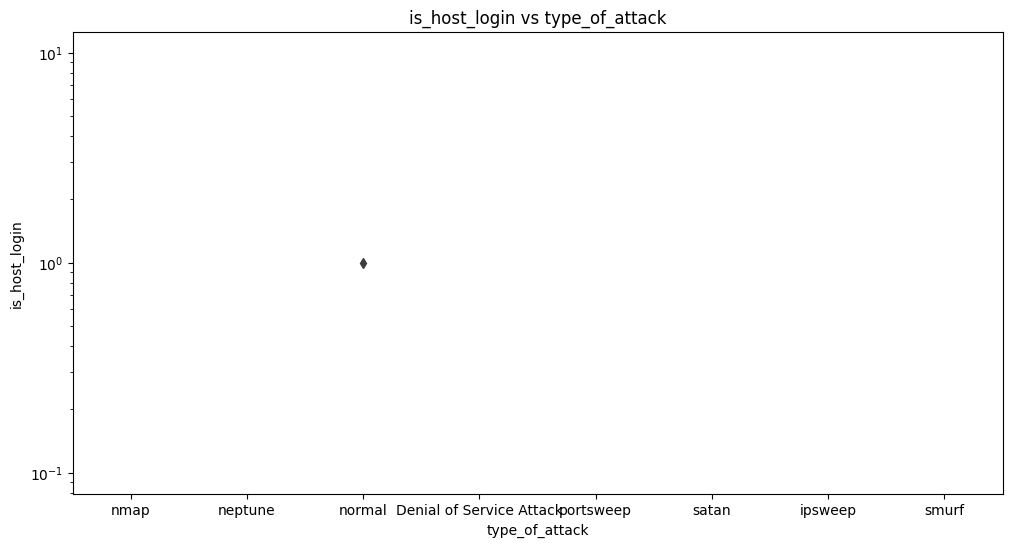

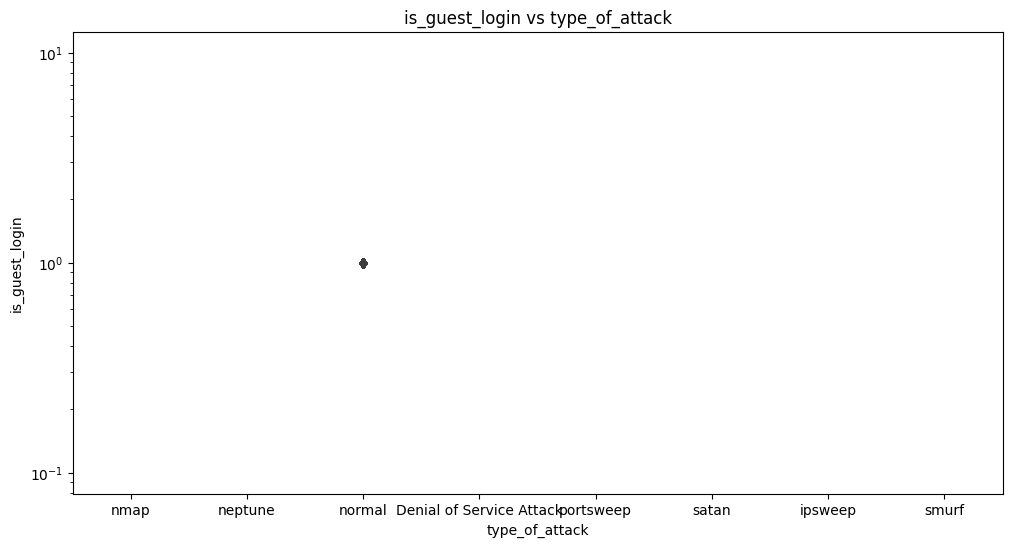

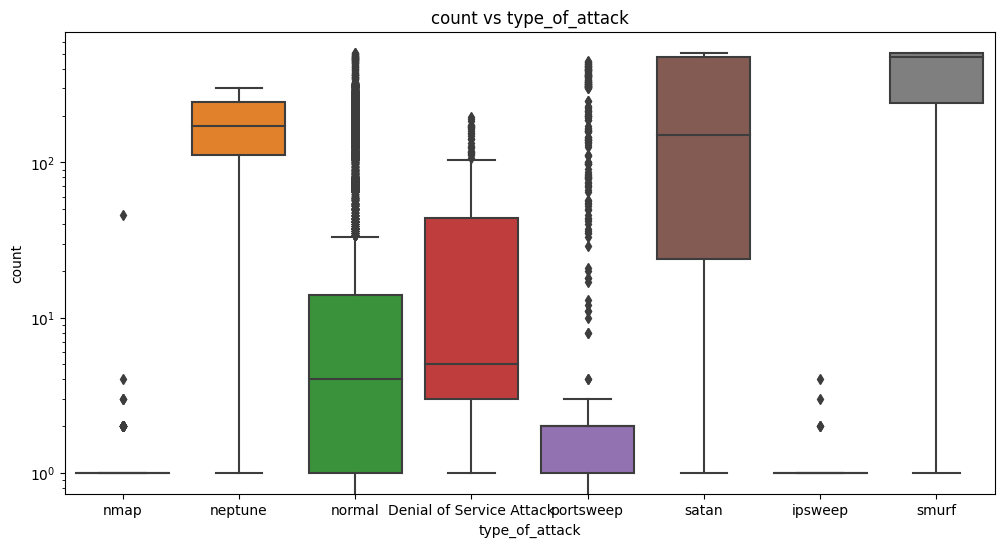

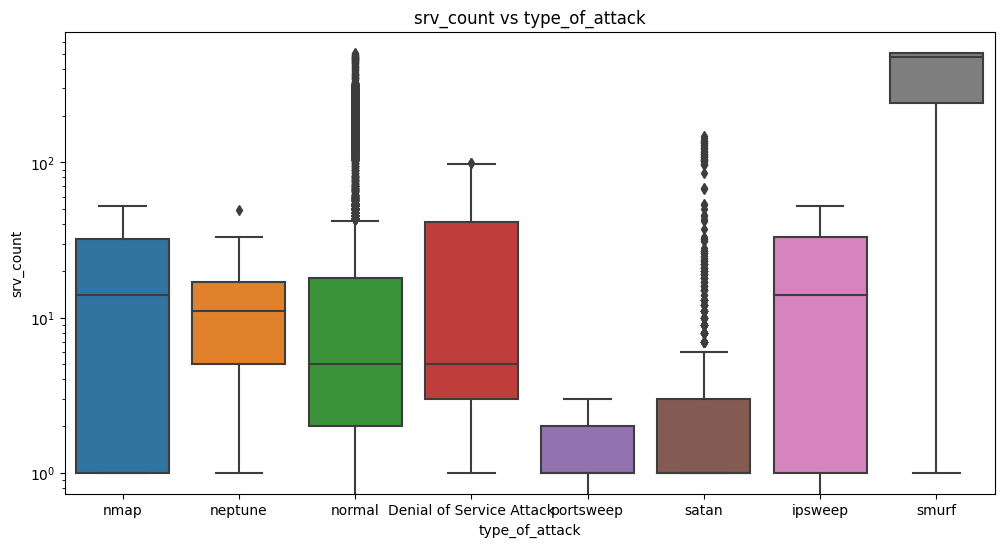

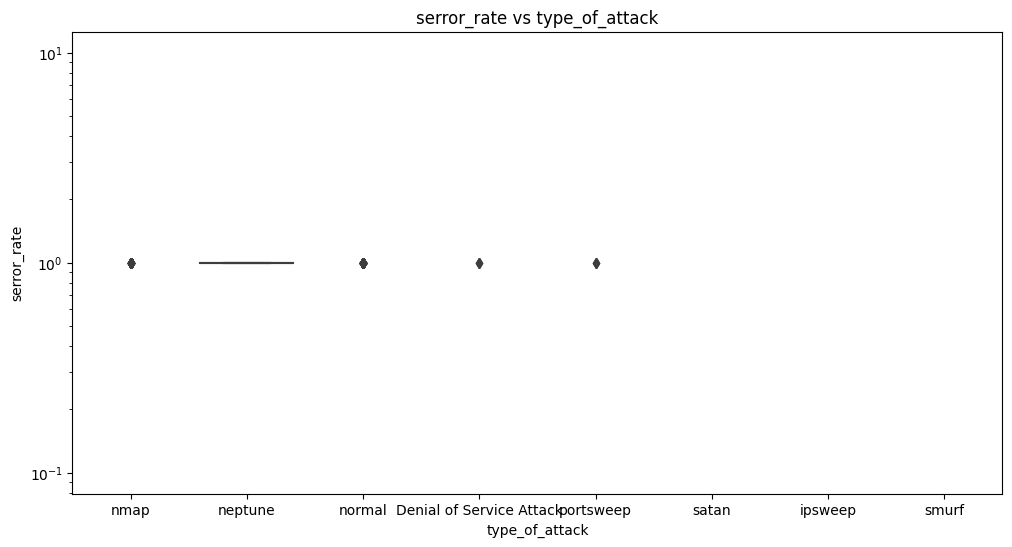

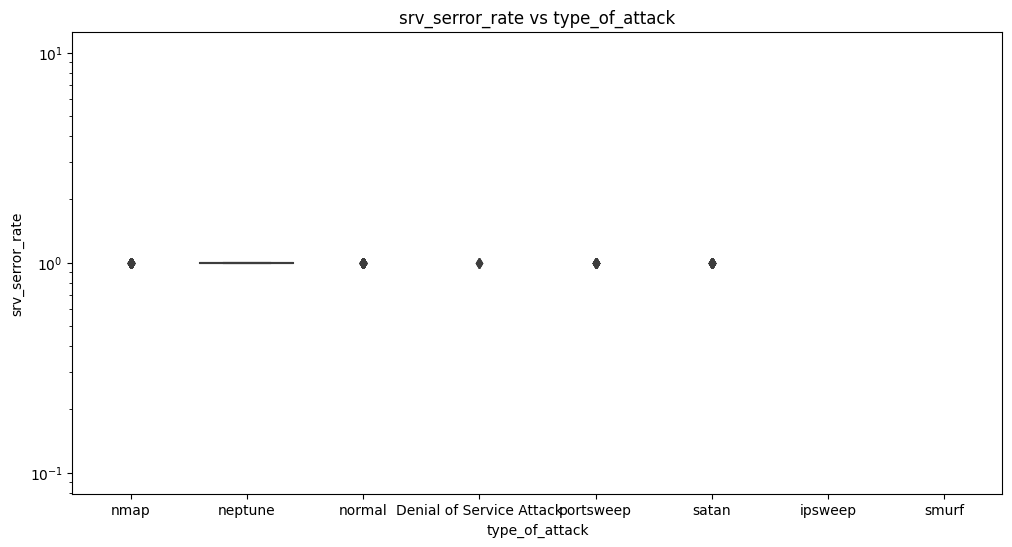

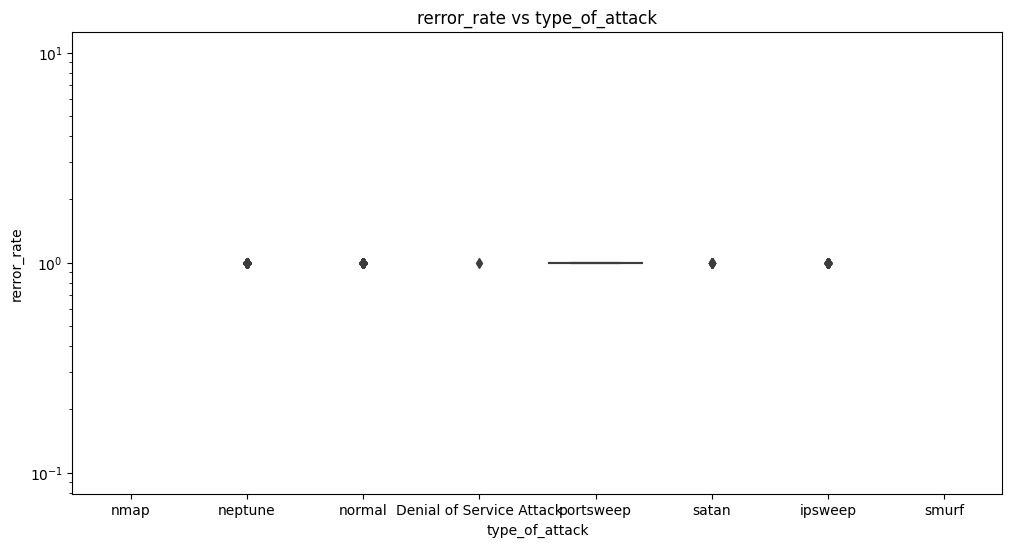

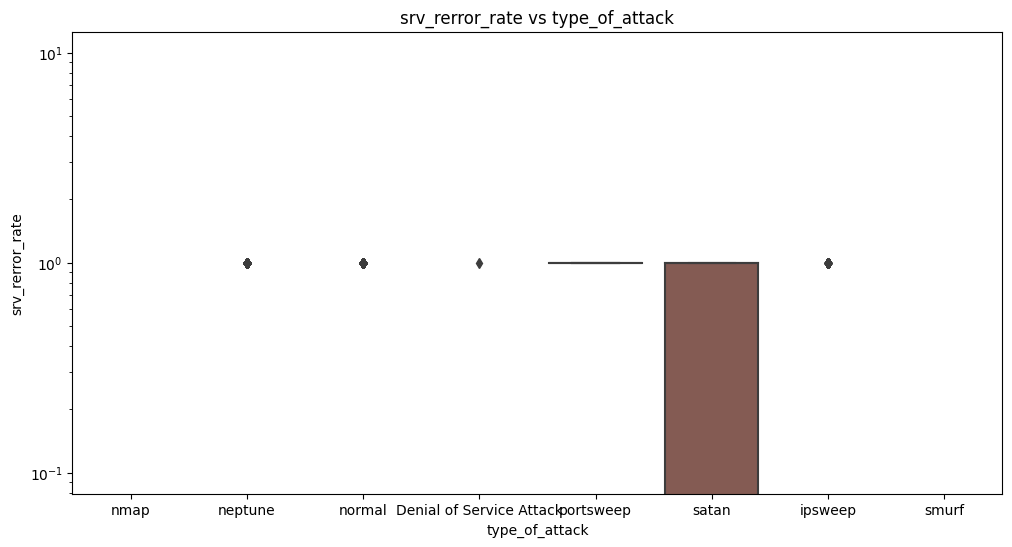

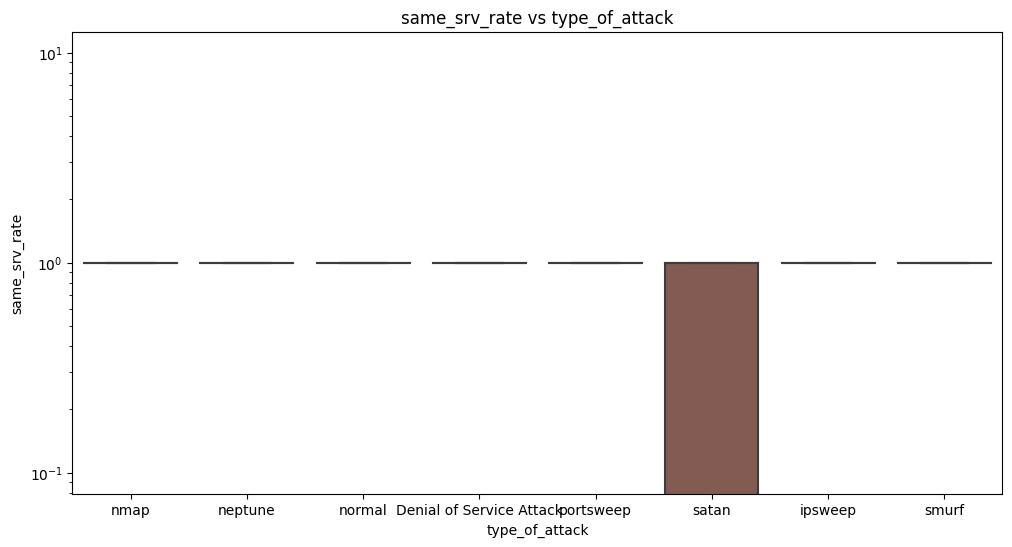

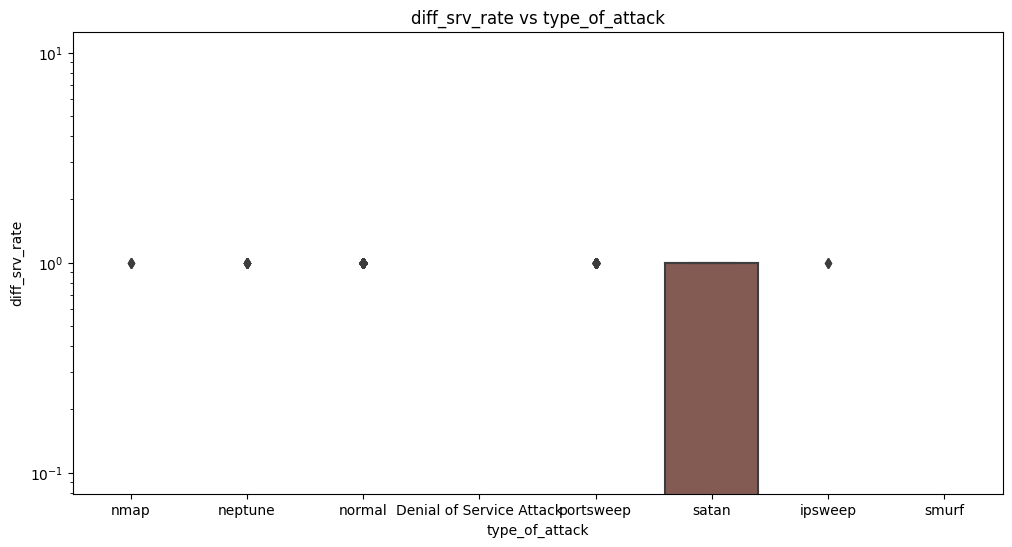

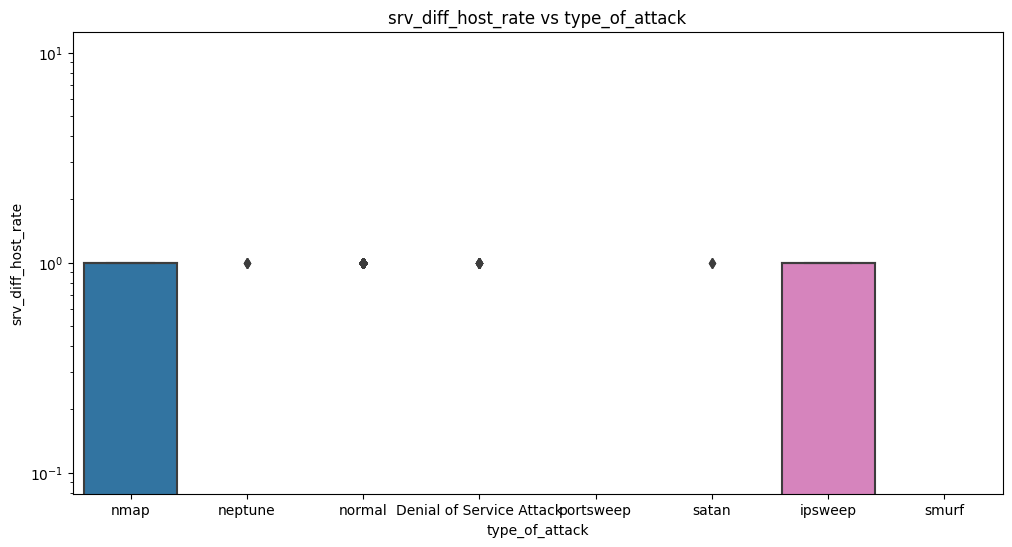

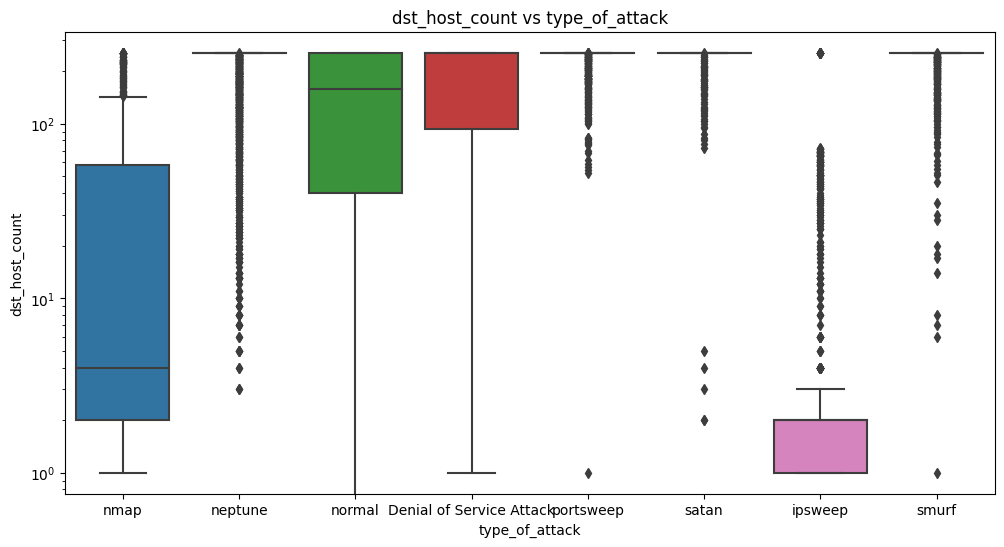

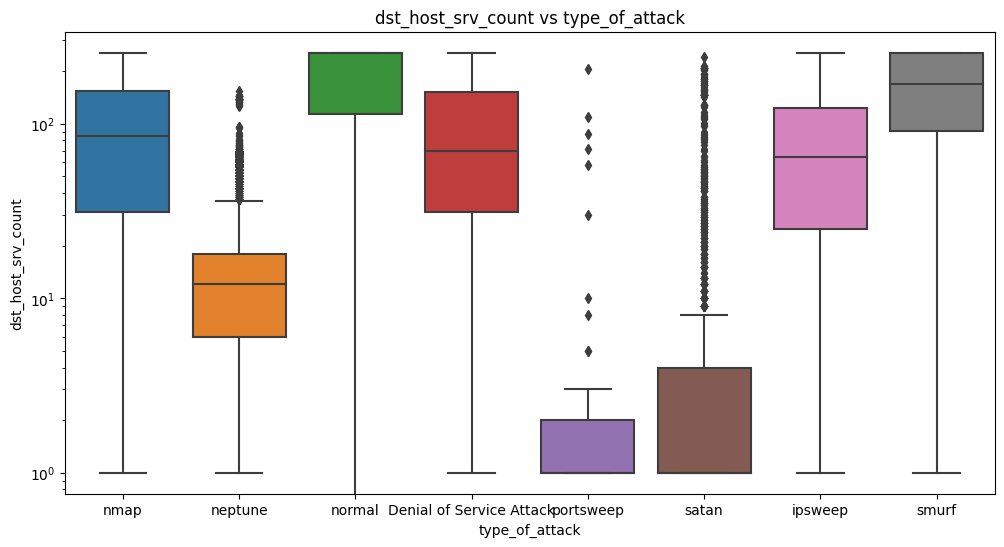

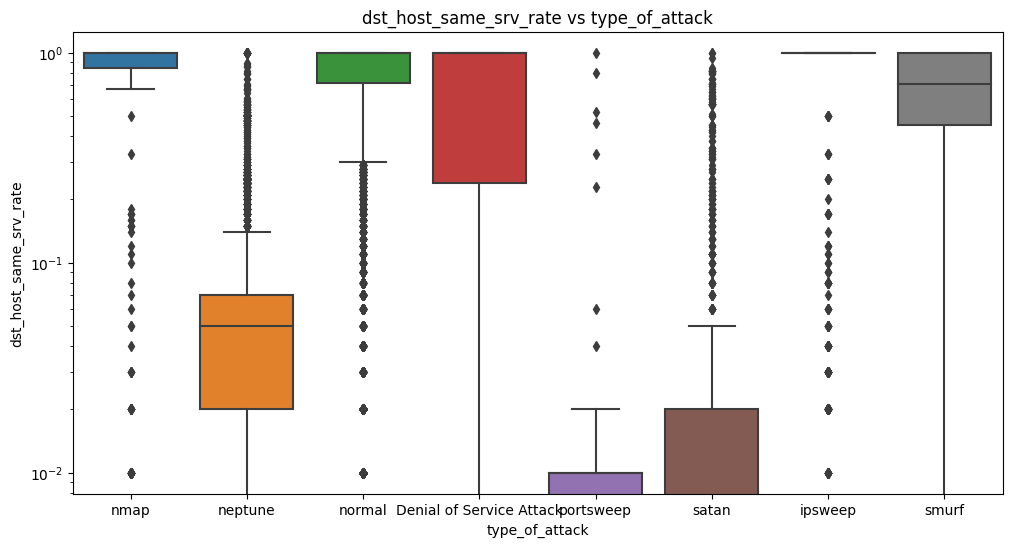

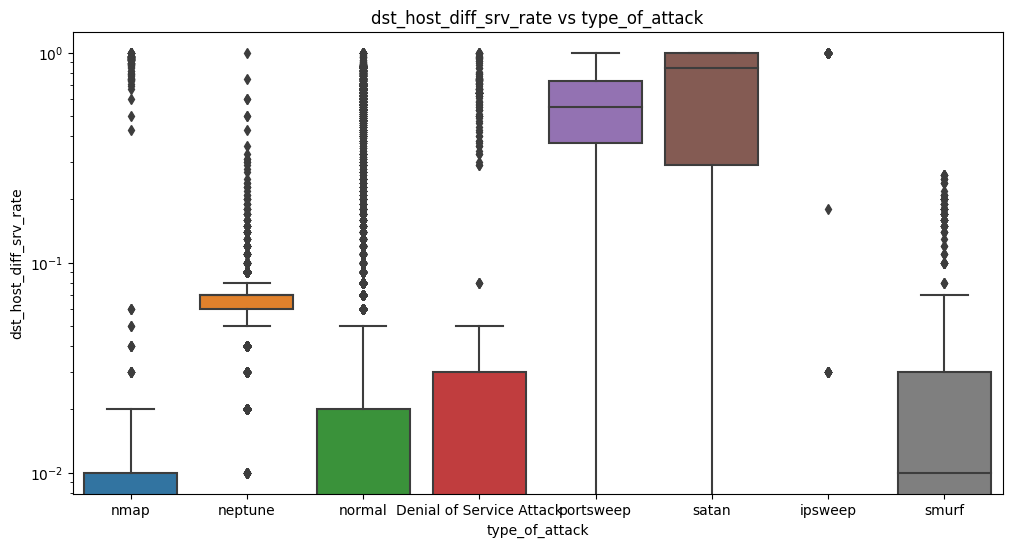

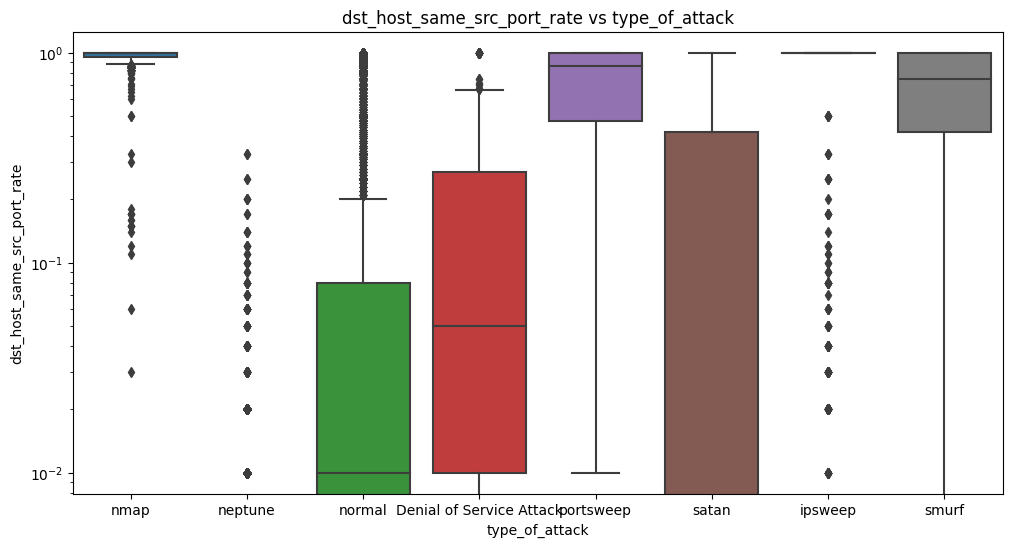

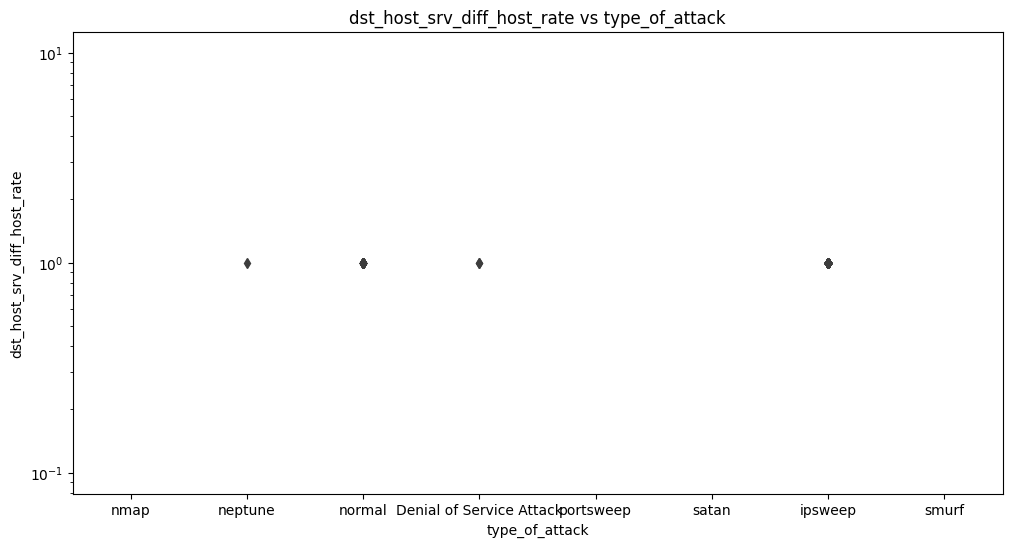

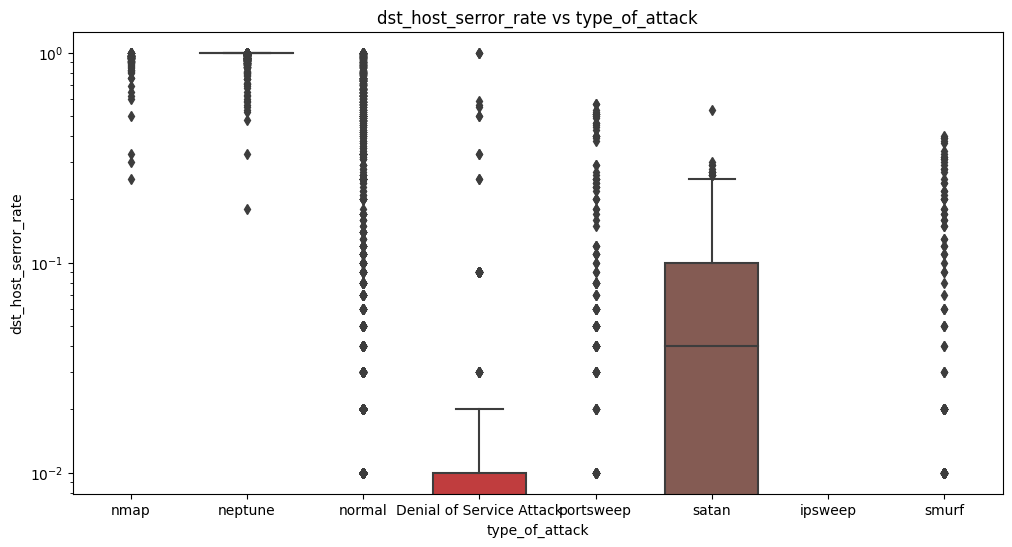

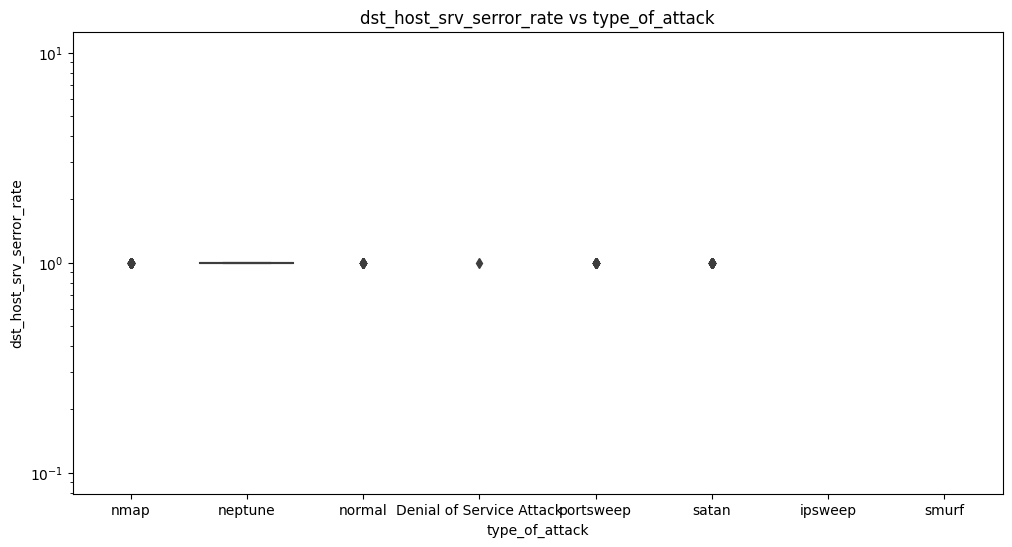

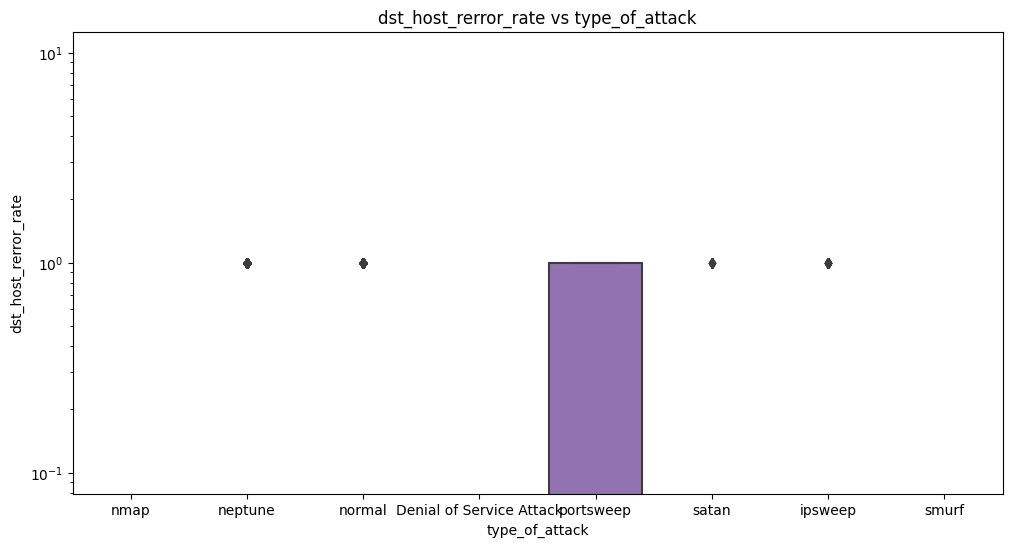

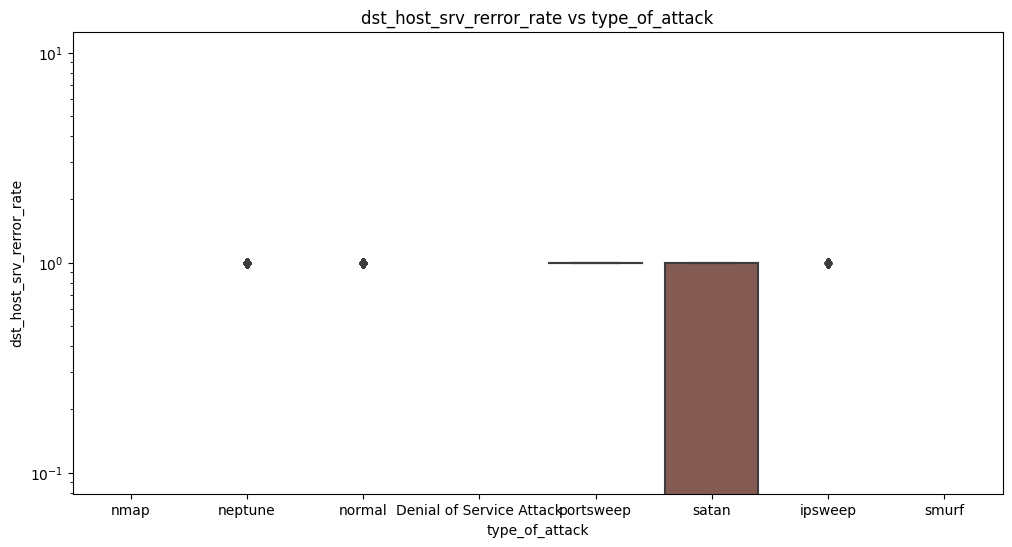

In [ ]:
data = newTrain

columns_to_plot = [col for col in data.columns if col != 'type_of_attack']

for column in columns_to_plot:
    plt.figure(figsize=(12, 6))
    if data[column].dtype == 'object':
        # CATEGORICAL buat count plot
        sns.countplot(x='type_of_attack', hue=column, data=data)
        plt.xticks(rotation=90)
    else:
        # NUMERIK box plot
        sns.boxplot(x='type_of_attack', y=column, data=data)
        plt.yscale('log')  # Jika skala logaritmik diperlukan
    plt.title(f'{column} vs type_of_attack')
    plt.show()

In [ ]:
## CRAMER V
import researchpy as rp

contingency_table = pd.crosstab(newTrain['type_of_attack'], newTrain['protocol_type'])

# Hitung Cramer's V
cramer_v = rp.crosstab(newTrain['type_of_attack'], newTrain['protocol_type'],
                       prop='cell')

# Tampilkan hasil
print(cramer_v)

ModuleNotFoundError: ignored

In [ ]:
contingency_table = pd.crosstab(newTrain['type_of_attack'], newTrain['service'])

cramer_v = rp.crosstab(newTrain['type_of_attack'], newTrain['service'],
                       prop='cell')

print(cramer_v)

In [ ]:
contingency_table = pd.crosstab(newTrain['type_of_attack'], newTrain['flag'])

cramer_v = rp.crosstab(newTrain['type_of_attack'], newTrain['flag'],
                       prop='cell')

print(cramer_v)

# Modelling

In [17]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.preprocessing import LabelEncoder


# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

Data Preprocessing

In [18]:
le = LabelEncoder()
newTrain['type_of_attack'] = le.fit_transform(newTrain['type_of_attack'])
newTrain['protocol_type'] = le.fit_transform(newTrain['protocol_type'])
newTrain['service'] = le.fit_transform(newTrain['service'])
newTrain['flag'] = le.fit_transform(newTrain['flag'])
newTrain['land'] = le.fit_transform(newTrain['land'])
newTrain['logged_in'] = le.fit_transform(newTrain['logged_in'])
newTrain['root_shell'] = le.fit_transform(newTrain['root_shell'])
newTrain['su_attempted'] = le.fit_transform(newTrain['su_attempted'])
newTrain['is_host_login'] = le.fit_transform(newTrain['is_host_login'])
newTrain['is_guest_login'] = le.fit_transform(newTrain['is_guest_login'])

In [19]:
newTrain.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,type_of_attack
0,0.0,1,49,10,0.0,0.0,0,0.0,0.0,0.0,...,1.0,0.01,0.94,0.95,0.0,0.95,1.0,0.0,0.0,3
1,0.0,1,49,5,0.0,0.0,0,0.0,0.0,0.0,...,5.0,0.02,0.08,0.00,0.0,1.00,1.0,0.0,0.0,2
2,0.0,1,24,9,285.0,3623.0,0,0.0,0.0,0.0,...,228.0,1.00,0.00,0.01,0.0,0.00,0.0,0.0,0.0,4
3,0.0,1,24,9,232.0,584.0,0,0.0,0.0,0.0,...,255.0,1.00,0.00,0.17,0.0,0.00,0.0,0.0,0.0,4
4,1.0,1,54,9,1080.0,327.0,0,0.0,0.0,0.0,...,154.0,0.58,0.02,0.00,0.0,0.00,0.0,0.0,0.0,4


In [20]:
# Split the data into features (X) and target (y)
X = newTrain.drop('type_of_attack', axis=1)
y = newTrain['type_of_attack']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [21]:
rf1 = RandomForestClassifier()
rf1.fit(X_train, y_train)

RandomForestClassifier()

In [22]:
y_pred = rf1.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9944419742107603


In [24]:
precission = precision_score(y_test, y_pred, average='weighted')
print("Precission:", precission)

Precission: 0.9943806512643123


In [26]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')
print("F1:", f1)

F1: 0.9944079505229605


Plotting one of the trees

In [27]:
tree = rf1.estimators_[5]
# Import tools needed for visualization
from sklearn.tree import export_graphviz
import pydot
# Pull out one tree from the forest
tree = rf1.estimators_[5]
# Export the image to a dot file
export_graphviz(tree, out_file = 'tree.dot', feature_names = X.columns, rounded = True, precision = 1)
# Use dot file to create a graph
(graph, ) = pydot.graph_from_dot_file('tree.dot')
# Write graph to a png file
graph.write_png('tree.png')

Making smaller easier to read trees

In [28]:
# Limit depth of tree to 3 levels
rf_small = RandomForestClassifier(n_estimators=10, max_depth = 3)
rf_small.fit(X_train, y_train)
# Extract the small tree
tree_small = rf_small.estimators_[5]
# Save the tree as a png image
export_graphviz(tree_small, out_file = 'small_tree.dot', feature_names = X.columns, rounded = True, precision = 1)
(graph, ) = pydot.graph_from_dot_file('small_tree.dot')
graph.write_png('small_tree.png');

## Use only variables with p-value of 0

In [29]:
X2 = X.filter(["logged_in", "count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "protocol_type", "service", "flag"])

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2)

In [30]:
rf2 = RandomForestClassifier()
rf2.fit(X2_train, y2_train)

y2_pred = rf2.predict(X2_test)

In [31]:
accuracy = accuracy_score(y2_test, y2_pred)
print("Accuracy:", accuracy)

Accuracy: 0.987638950644731


In [32]:
precission = precision_score(y2_test, y2_pred, average='weighted')
print("Precission:", precission)

Precission: 0.9873165084641145


Import Predictors Data

In [ ]:
dataPredict = pd.read_csv("./Data_Prediction.csv", sep=";", na_values=["*", 99999, "#NA"])

In [ ]:
dataPredict['flag'] = le.fit_transform(dataPredict['flag'])
dataPredict['protocol_type'] = le.fit_transform(dataPredict['protocol_type'])
dataPredict['service'] = le.fit_transform(dataPredict['service'])

In [ ]:
dataPredict.head()

,id,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,1,1,1,50,9,2397,328,0,0,0,...,179,182,0.68,0.02,0.01,0.01,0.0,0.0,0.0,0.0
1,2,990,2,41,9,145,105,0,0,0,...,255,1,0.00,0.64,0.94,0.00,0.0,0.0,0.0,0.0
2,3,0,0,14,9,1032,0,0,0,0,...,255,23,0.09,0.02,0.09,0.00,0.0,0.0,0.0,0.0
3,4,0,0,13,9,8,0,0,0,0,...,1,85,1.00,0.00,1.00,0.51,0.0,0.0,0.0,0.0
4,5,0,2,11,9,44,132,0,0,0,...,250,101,0.40,0.01,0.38,0.00,0.0,0.0,0.0,0.0


In [ ]:
id = dataPredict['id']
dataPredict.drop('id', axis=1, inplace=True)
predicted = rf1.predict(dataPredict)

In [ ]:
predicted

array([4, 4, 7, ..., 4, 3, 4])

In [ ]:
predicted = le.inverse_transform(predicted)

In [ ]:
predicted

array(['bgp', 'bgp', 'ctf', ..., 'bgp', 'auth', 'bgp'], dtype=object)